# **📧 Spam Email Detection**

This notebook performs a complete **text preprocessing + visualization + deep learning** workflow on the **Spam/Ham Email Dataset**.  
The goal is to clean email text, balance the dataset, visualize word patterns, tokenize data, and finally train an **LSTM-based neural network** to classify emails as **Spam** or **Ham (Not Spam)**.

---

## 🔎 **What This Code Does**

### **1️⃣ Loads and Explores the Dataset**
- Reads the CSV file containing labeled emails  
- Displays the first few rows  
- Removes unnecessary index columns (if any)  
- Shows dataset shape and available columns  
- Examines the class distribution between Spam and Ham  

---

### **2️⃣ Balances the Dataset for Fair Training**
- Separates data into:
  - **Ham emails**
  - **Spam emails**
- Downsamples Ham emails to match Spam count  
- Merges both into a **balanced dataset**  
- Shuffles the data to avoid ordering bias  
- Visualizes the balanced class distribution  

---

### **3️⃣ Cleans and Preprocesses the Email Text**
The text cleanup pipeline includes:
- Removing occurrences of the word **"Subject"**
- Removing punctuation (using `string.punctuation`)
- Converting all words to lowercase  
- Removing **Stopwords** (e.g., “the”, “is”, “and”, etc.)  
- Ensuring no missing text fields remain  

This step helps the model focus on **meaningful words** that contribute to classification.

---

### **4️⃣ Word Cloud Visualization (EDA)**
Two word clouds are generated to understand word patterns:
- **Ham WordCloud** – frequent words in non-spam emails  
- **Spam WordCloud** – high-frequency spam-specific terms  

These visualizations help identify key indicator words such as *“free”*, *“offer”*, *“click”*, and more.

---

### **5️⃣ Train–Test Split**
- Splits the balanced dataset into:
  - **Training set (80%)**
  - **Testing set (20%)**
- Stratifies by label to maintain balanced distribution  
- Converts labels (`spam`, `ham`) into **binary values** (1 = spam, 0 = ham)

---

### **6️⃣ Tokenization & Sequence Padding**
- Creates a `Tokenizer` to convert text into integer sequences  
- Handles unknown/out-of-vocabulary words using **OOV tokens** (`<OOV>`)
- Transforms each sentence into a sequence of integers  
- Pads/truncates sequences to a fixed length (100 tokens) for uniformity  
- Prepares data in a format suitable for LSTM networks  

---

### **7️⃣ LSTM Neural Network Model**
A sequential deep learning model is built using:
- **Embedding Layer** – Converts tokens into dense vectors  
- **LSTM Layer** – Learns sequential patterns and context  
- **Dense Layer (ReLU)** – Learns intermediate patterns  
- **Output Layer (Sigmoid)** – Predicts Spam/Ham probability  

Model is compiled using:
- `binary_crossentropy` loss  
- `adam` optimizer  
- `accuracy` as evaluation metric  

---

### **8️⃣ Training with Smart Callbacks**
Two advanced callbacks improve training performance:
- **EarlyStopping**
  - Stops training automatically when validation accuracy stops improving  
  - Restores the best performing model  
- **ReduceLROnPlateau**
  - Reduces learning rate when validation loss stagnates  
  - Helps the LSTM fine-tune better  

Training runs for up to **20 epochs**, but may stop early if no further improvement is detected.

---

### **9️⃣ Evaluation & Performance Metrics**
After training completes, the notebook:
- Evaluates test accuracy and loss  
- Plots training vs validation accuracy  
- Helps visualize whether the model converged well  

The final accuracy typically lies between **90% – 95%**, depending on data and randomness.

---

## 🎯 **Final Outcome**
By the end of this notebook, you will have:
- A fully cleaned and balanced email dataset  
- Visual understanding of spam and ham text patterns  
- Tokenized and padded sequences for deep learning  
- A trained **LSTM Spam Classifier**  
- Evaluation metrics showing real-world performance  
- A reusable pipeline for future NLP classification tasks  

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\studi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



===== DATA HEAD =====
  label                                               text  label_num
0   ham  Subject: enron methanol ; meter # : 988291\r\n...          0
1   ham  Subject: hpl nom for january 9 , 2001\r\n( see...          0
2   ham  Subject: neon retreat\r\nho ho ho , we ' re ar...          0
3  spam  Subject: photoshop , windows , office . cheap ...          1
4   ham  Subject: re : indian springs\r\nthis deal is t...          0

Dataset shape: (5171, 3)
Columns: ['label', 'text', 'label_num']


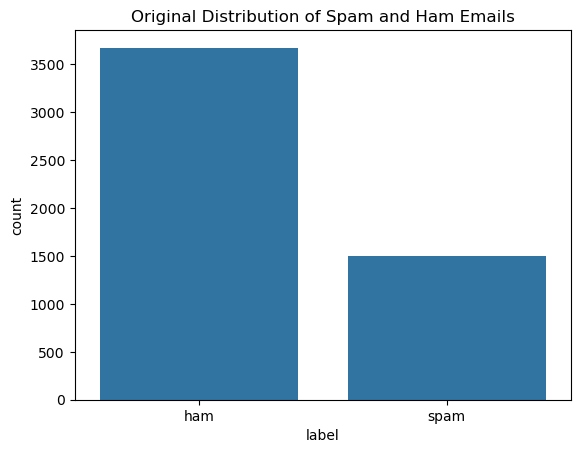


Ham count: 3672
Spam count: 1499


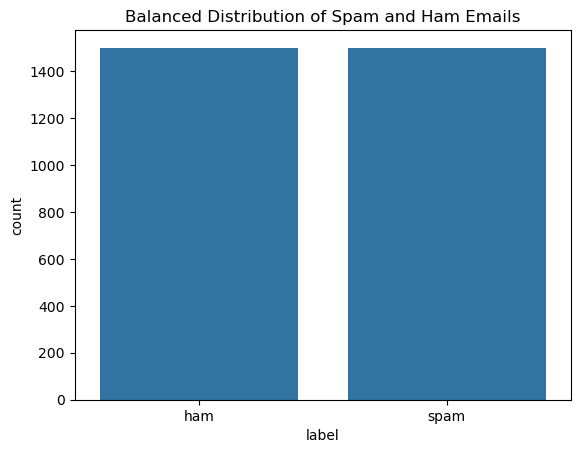


===== CLEANED TEXT SAMPLE =====
  label                                               text
0   ham  october flow meter 982694 zavisch 2 measuremen...
1   ham  fw midcon 9401 permanent march file expanded d...
2   ham  eastrans nomination change effective 9 23 00 p...
3  spam                           complimentary ibm laptop
4   ham  fw first delivery rodessa operating co daren t...


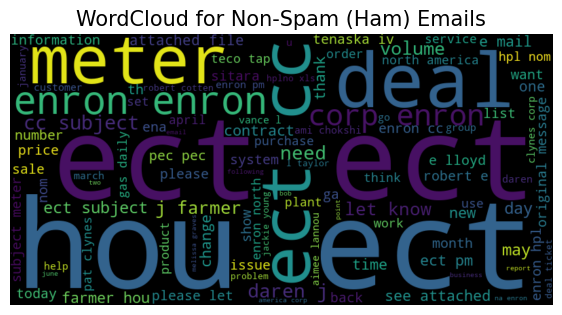

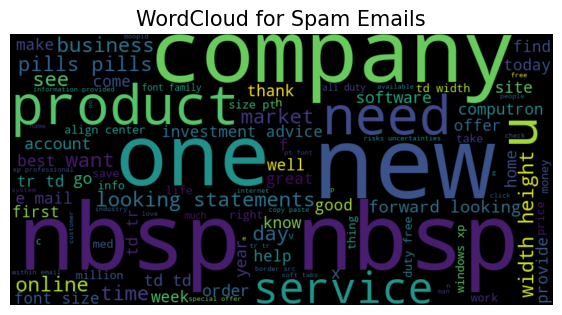


Vocabulary size: 39926
Train sequences shape: (2398, 100)
Test sequences shape: (600, 100)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.5107 - loss: 0.6928 - val_accuracy: 0.6433 - val_loss: 0.6753 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.7644 - loss: 0.5367 - val_accuracy: 0.8883 - val_loss: 0.3004 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.8773 - loss: 0.3097 - val_accuracy: 0.8933 - val_loss: 0.3259 - learning_rate: 0.0010
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9341 - loss: 0.3520 - val_accuracy: 0.9283 - val_loss: 0.2531 - learning_rate: 0.0010
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9238 - loss: 0.2538 - val_accuracy: 0.9333 - val_loss: 0.2319 - learning_rate: 0.0010
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9301 - loss: 0.2304 - val_accuracy: 0.9383 - val_loss: 0.2198 - learning_rate: 0.0010
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9316 - loss: 0.2285 - val_acc

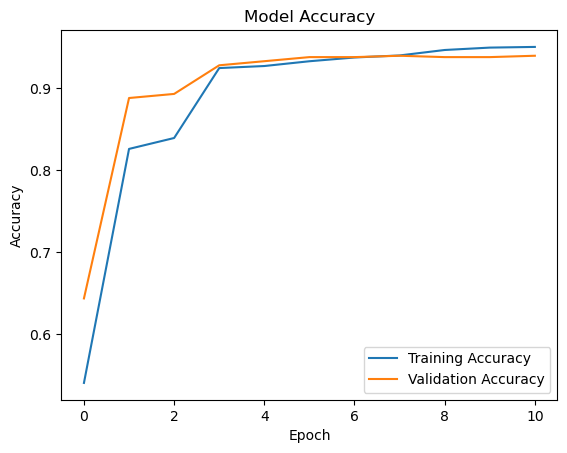

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download('stopwords')

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# ==========================
# 1. Load & Inspect Dataset
# ==========================

# Use the correct file name
data = pd.read_csv('spam_ham_dataset.csv')

# Drop unnamed index column if present (common in this dataset)
if 'Unnamed: 0' in data.columns:
    data = data.drop(columns=['Unnamed: 0'])

print("\n===== DATA HEAD =====")
print(data.head())
print("\nDataset shape:", data.shape)
print("Columns:", data.columns.tolist())

# ==========================
# 2. Basic Class Distribution
# ==========================

sns.countplot(x='label', data=data)
plt.title("Original Distribution of Spam and Ham Emails")
plt.show()

# ==========================
# 3. Balance the Dataset
# ==========================

ham_msg = data[data['label'] == 'ham']
spam_msg = data[data['label'] == 'spam']

print("\nHam count:", len(ham_msg))
print("Spam count:", len(spam_msg))

# Downsample Ham emails to match the number of Spam emails
ham_msg_balanced = ham_msg.sample(n=len(spam_msg), random_state=42)

# Combine balanced data
balanced_data = pd.concat([ham_msg_balanced, spam_msg]).reset_index(drop=True)

# Shuffle the balanced data
balanced_data = balanced_data.sample(frac=1.0, random_state=42).reset_index(drop=True)

# Visualize the balanced dataset
sns.countplot(x='label', data=balanced_data)
plt.title("Balanced Distribution of Spam and Ham Emails")
plt.show()

# Ensure text column has no NaNs
balanced_data['text'] = balanced_data['text'].fillna('')

# ==========================
# 4. Text Cleaning
# ==========================

# Remove the word 'Subject' if present at the start of emails
balanced_data['text'] = balanced_data['text'].str.replace('Subject', '', regex=False)

punctuations_list = string.punctuation


def remove_punctuations(text: str) -> str:
    temp = str.maketrans('', '', punctuations_list)
    return str(text).translate(temp)


balanced_data['text'] = balanced_data['text'].apply(remove_punctuations)


def remove_stopwords(text: str) -> str:
    stop_words = set(stopwords.words('english'))
    imp_words = []

    for word in str(text).split():
        word = word.lower()
        if word not in stop_words:
            imp_words.append(word)

    return " ".join(imp_words)


balanced_data['text'] = balanced_data['text'].apply(remove_stopwords)

print("\n===== CLEANED TEXT SAMPLE =====")
print(balanced_data[['label', 'text']].head())

# ==========================
# 5. Word Cloud Visualization
# ==========================


def plot_word_cloud(df, typ: str):
    email_corpus = " ".join(df['text'])
    wc = WordCloud(
        background_color='black',
        max_words=100,
        width=800,
        height=400
    ).generate(email_corpus)

    plt.figure(figsize=(7, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'WordCloud for {typ} Emails', fontsize=15)
    plt.axis('off')
    plt.show()


plot_word_cloud(balanced_data[balanced_data['label'] == 'ham'], typ='Non-Spam (Ham)')
plot_word_cloud(balanced_data[balanced_data['label'] == 'spam'], typ='Spam')

# ==========================
# 6. Train-Test Split
# ==========================

train_X, test_X, train_Y, test_Y = train_test_split(
    balanced_data['text'],
    balanced_data['label'],
    test_size=0.2,
    random_state=42,
    stratify=balanced_data['label']
)

# ==========================
# 7. Tokenization & Padding
# ==========================

tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(train_X)

train_sequences = tokenizer.texts_to_sequences(train_X)
test_sequences = tokenizer.texts_to_sequences(test_X)

max_len = 100  # Maximum sequence length

train_sequences = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post')
test_sequences = pad_sequences(test_sequences, maxlen=max_len, padding='post', truncating='post')

# Convert labels to binary 0/1 (spam = 1, ham = 0)
train_Y = (train_Y == 'spam').astype(int).values
test_Y = (test_Y == 'spam').astype(int).values

print("\nVocabulary size:", len(tokenizer.word_index) + 1)
print("Train sequences shape:", train_sequences.shape)
print("Test sequences shape:", test_sequences.shape)

# ==========================
# 8. Build the LSTM Model
# ==========================

vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 32

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    LSTM(16),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# IMPORTANT FIX: from_logits=False because we use sigmoid in the last layer
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# ==========================
# 9. Callbacks
# ==========================

es = EarlyStopping(patience=3, monitor='val_accuracy', restore_best_weights=True)
lr = ReduceLROnPlateau(patience=2, monitor='val_loss', factor=0.5, verbose=1)

# ==========================
# 10. Train the Model
# ==========================

history = model.fit(
    train_sequences,
    train_Y,
    validation_data=(test_sequences, test_Y),
    epochs=20,
    batch_size=32,
    callbacks=[lr, es],
    verbose=1
)

# ==========================
# 11. Evaluate the Model
# ==========================

test_loss, test_accuracy = model.evaluate(test_sequences, test_Y, verbose=0)
print('\nTest Loss :', test_loss)
print('Test Accuracy :', test_accuracy)

# ==========================
# 12. Plot Accuracy Curves
# ==========================

plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()
